In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
dlinear = pd.read_csv("results/DLinear/rel_error.csv")
timesnet = pd.read_csv("results/TimesNet/32_rel_erreur.csv")
transformer = pd.read_csv("results/Transformer/32_e2.csv")
timemixer = pd.read_csv("results/TimeMixer/32.csv")


dlinear["model"] = "DLinear"
timesnet["model"] = "TimesNet"
transformer["model"] = "Transformer"
timemixer["model"] = "TimeMixer"

df = pd.concat([dlinear, timesnet, transformer, timemixer], ignore_index=True)
df["rel_ratio"] = df["rel_abnormal"] / df["rel_normal"]
df["top1_ratio"] = df["top1_abnormal"] / df["top1_normal"]

# Optional: avoid inf / nan if division issues exist
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [8]:
metrics = [
    "rel_normal",
    "rel_abnormal",
    "rel_ratio",
    "top1_normal",
    "top1_abnormal",
    "top1_ratio",
    "AUC-PR",
    "AUC-ROC",
    "Standard-F1",
]

df_melted = df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

NameError: name 'titles' is not defined

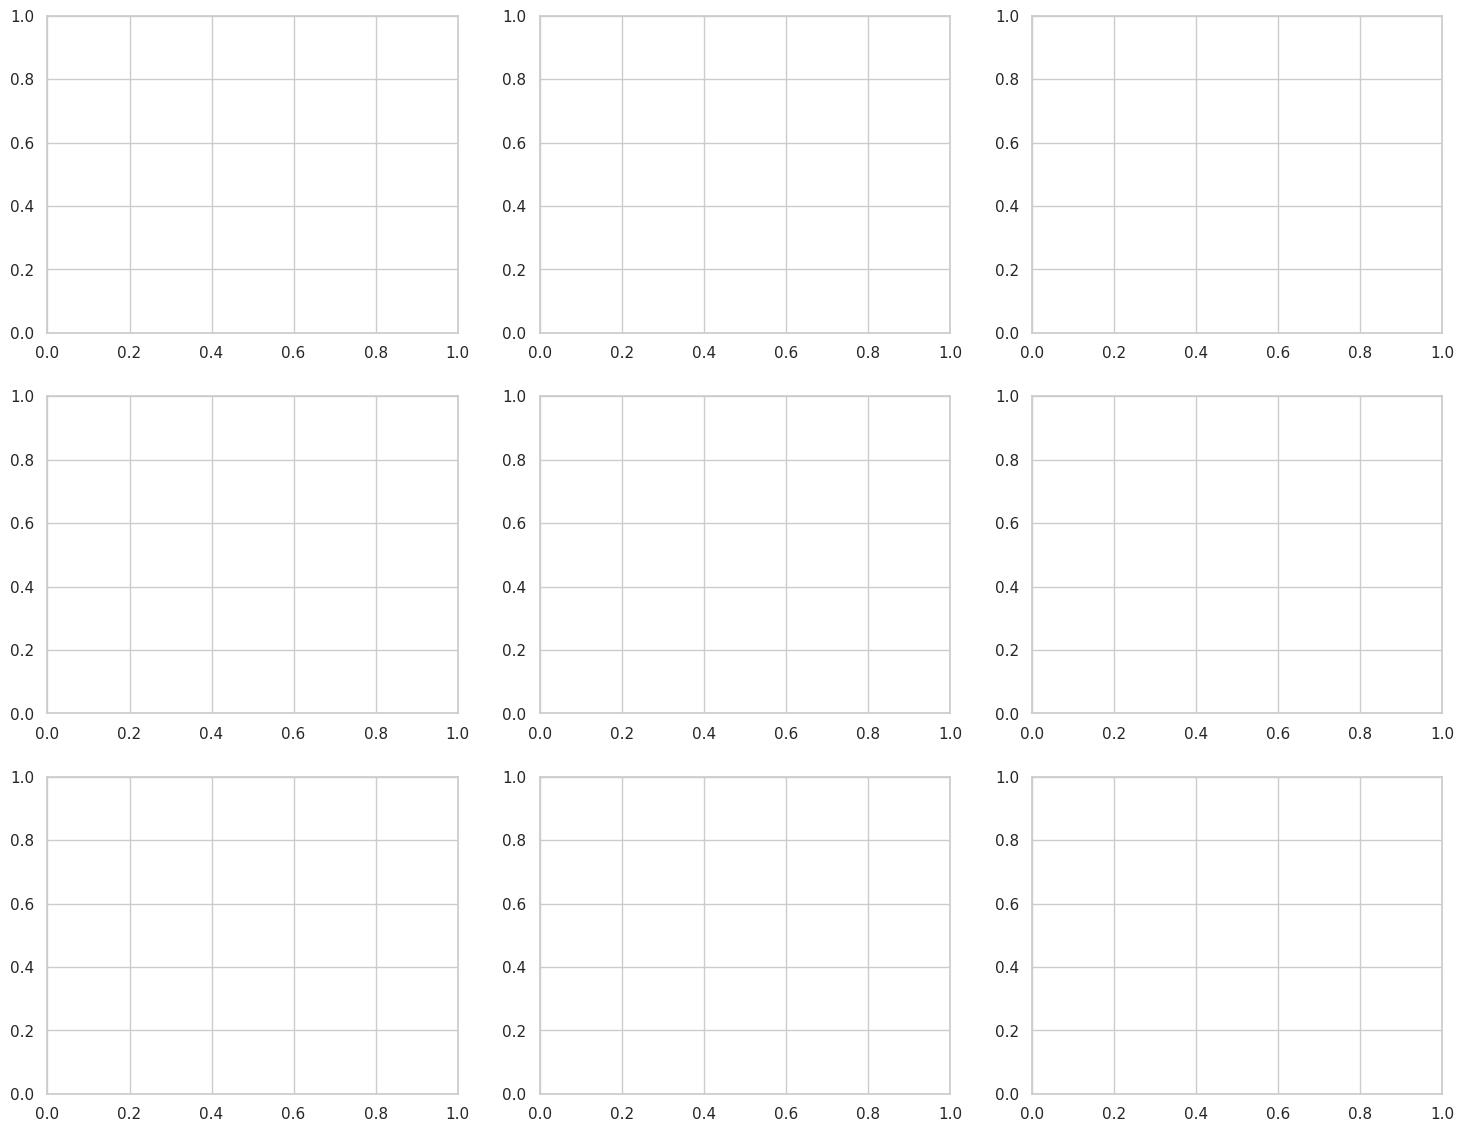

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, metric, title in zip(axes, metrics, titles):
    sns.boxplot(
        data=df,
        x="model",
        y=metric,
        ax=ax,
        showfliers=False,
        showmeans=True
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")

# Log-scale ratios (recommended)
axes[2].set_yscale("log")
axes[5].set_yscale("log")

plt.suptitle("Model Comparison: Error Metrics, Ratios, and Detection Performance", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


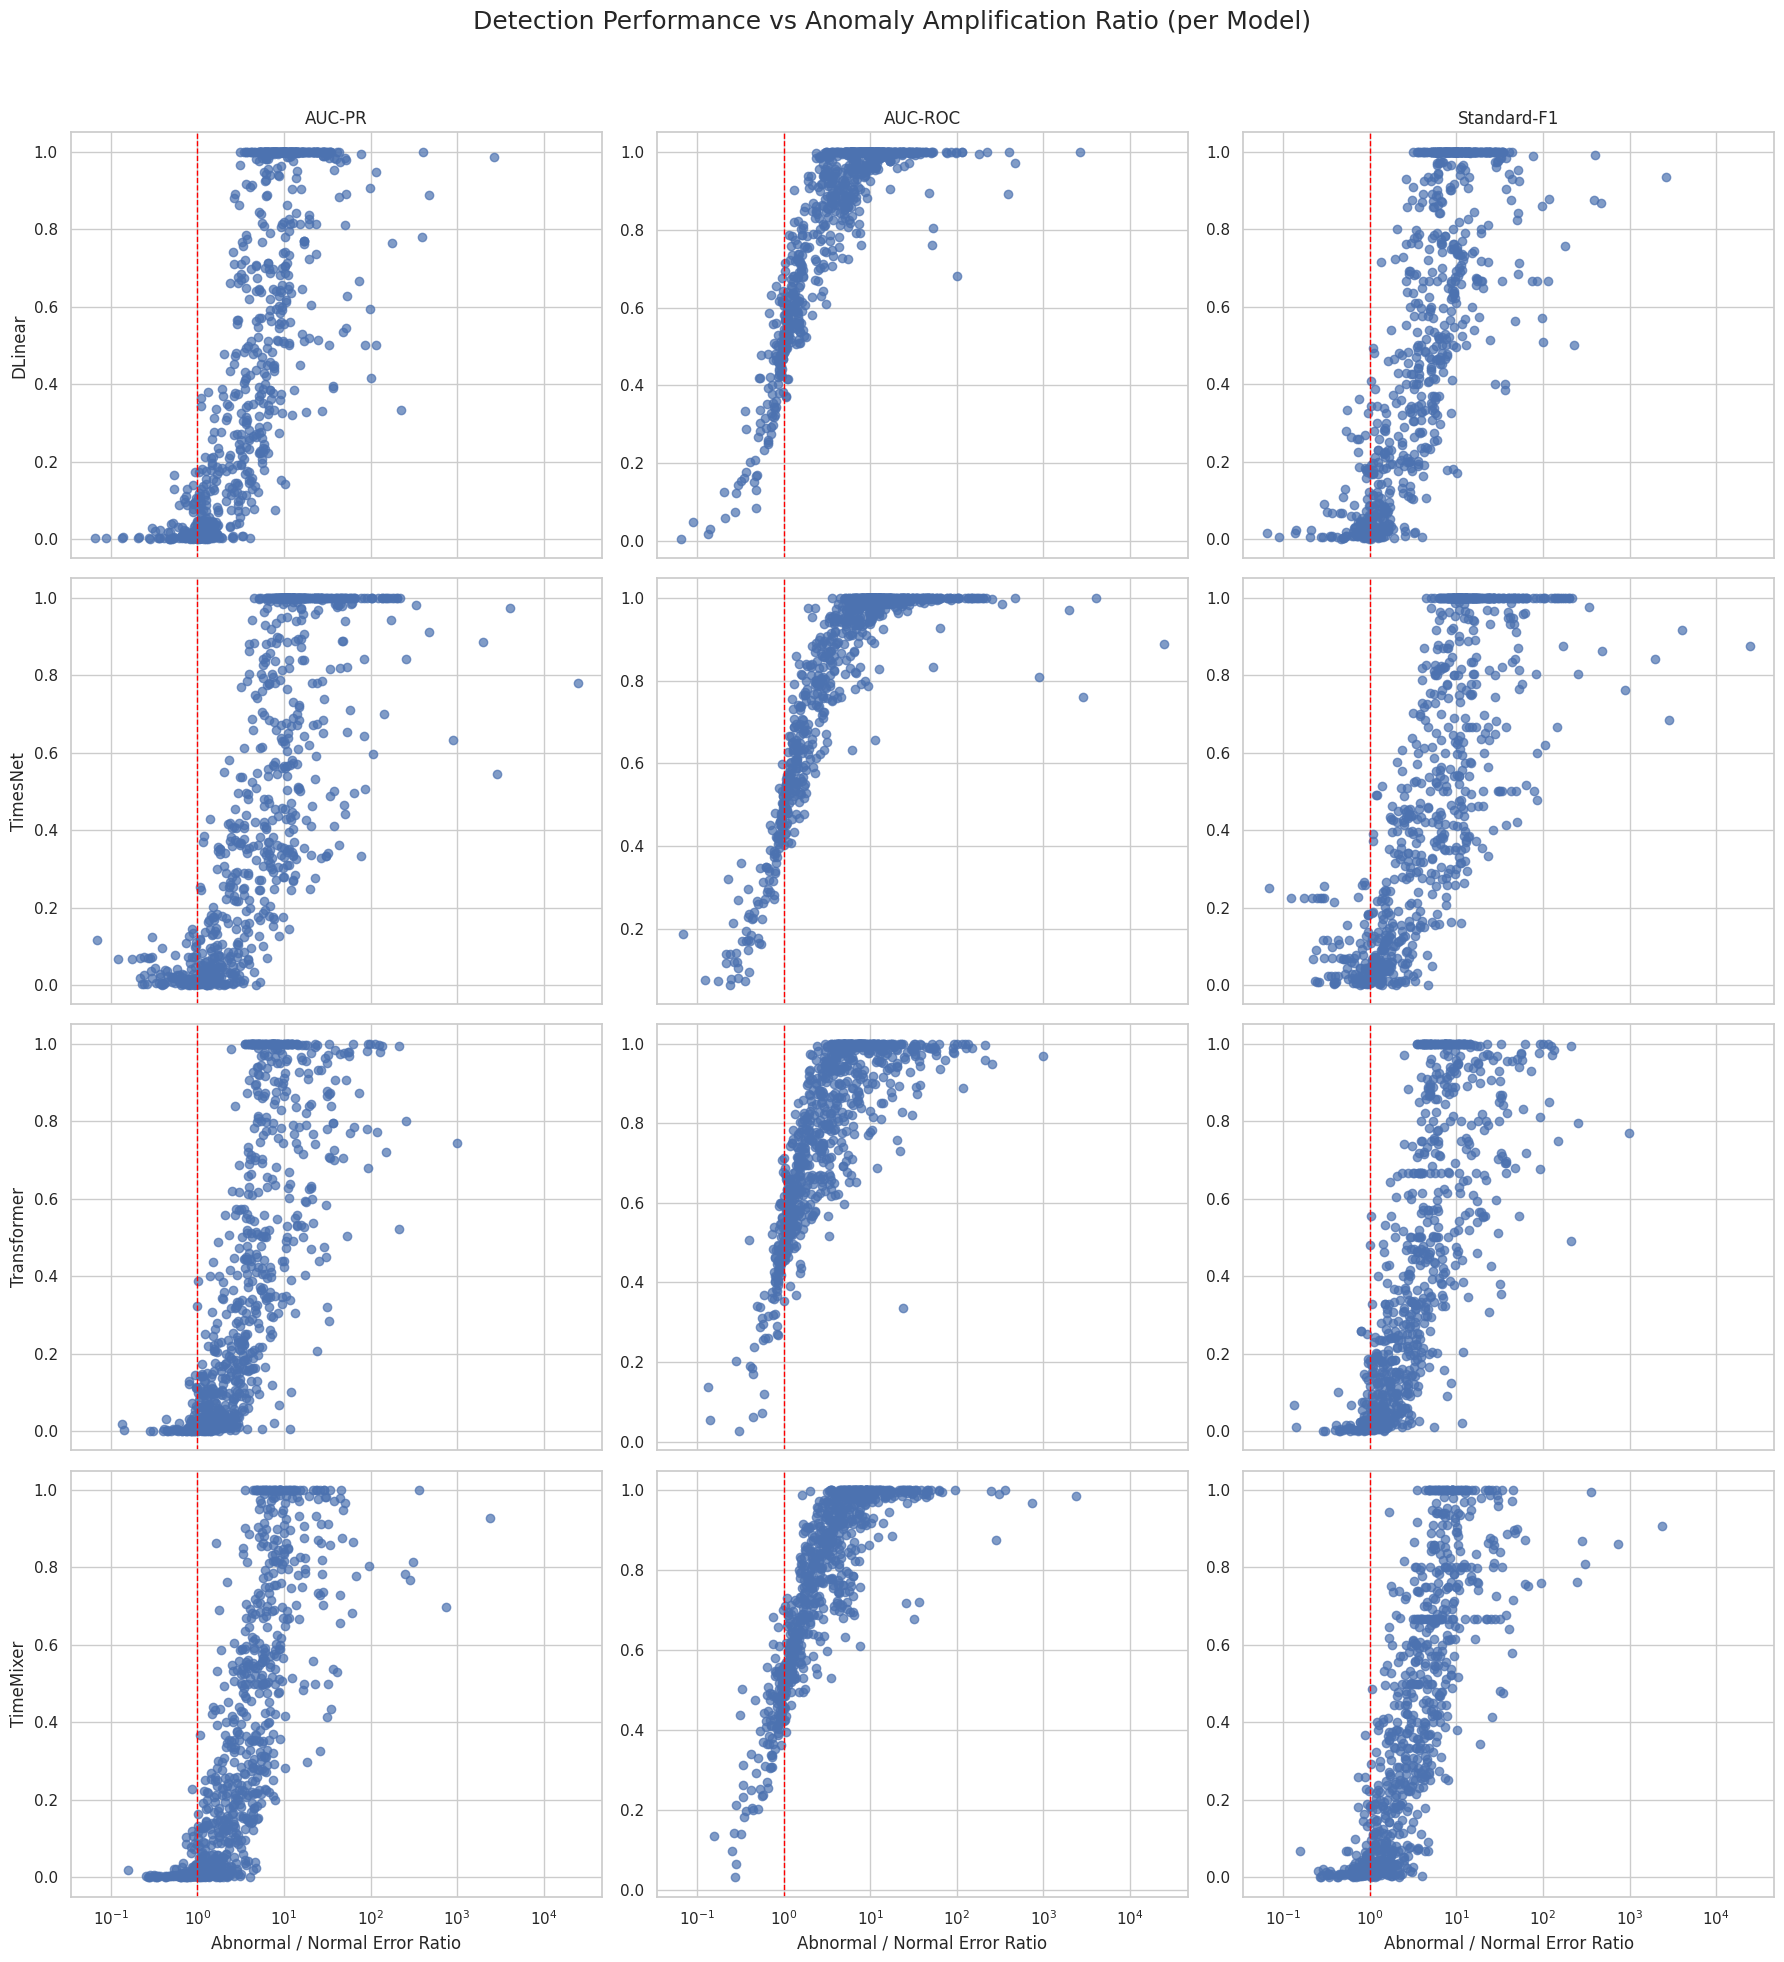

In [10]:
models = ["DLinear", "TimesNet", "Transformer", "TimeMixer"]
metrics = ["AUC-PR", "AUC-ROC", "Standard-F1"]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18, 20),
    sharex=True
)

for i, model in enumerate(models):
    subset = df[df["model"] == model]

    for j, metric in enumerate(metrics):
        ax = axes[i, j]

        ax.scatter(
            subset["rel_ratio"],   # rel_ratio  top1_ratio
            subset[metric],
            alpha=0.7
        )

        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1,
            color= "red"
        )

        ax.set_xscale("log")

        if i == 0:
            ax.set_title(metric)

        if j == 0:
            ax.set_ylabel(model)

        if i == len(models) - 1:
            ax.set_xlabel("Abnormal / Normal Error Ratio")

plt.suptitle(
    "Detection Performance vs Anomaly Amplification Ratio (per Model)",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

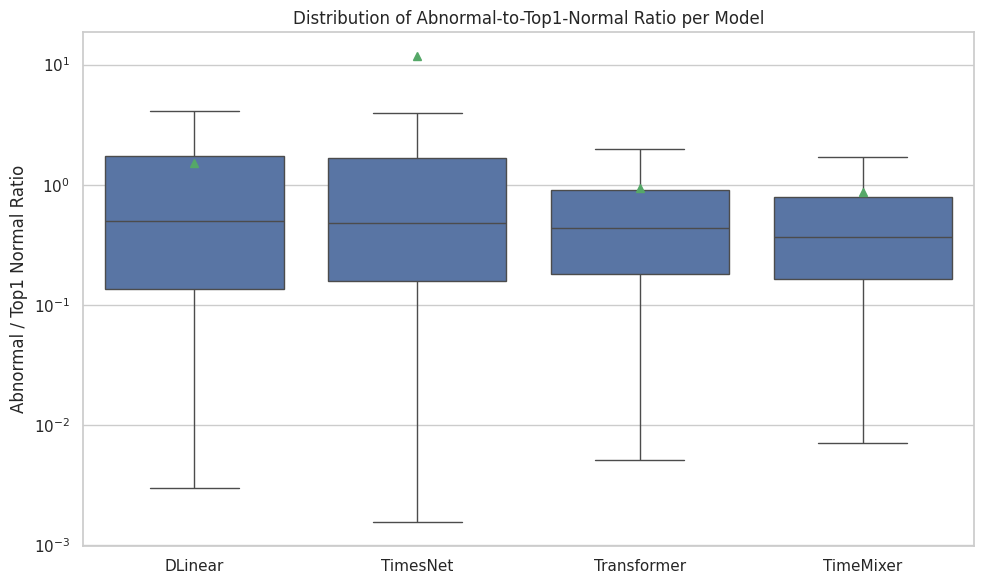

In [11]:
df["abn_over_top1_norm"] = df["rel_abnormal"] / df["top1_normal"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="model",
    y="abn_over_top1_norm",
    showfliers=False,
    showmeans=True
)

plt.yscale("log")  # strongly recommended for ratios
plt.ylabel("Abnormal / Top1 Normal Ratio")
plt.xlabel("")
plt.title("Distribution of Abnormal-to-Top1-Normal Ratio per Model")

plt.tight_layout()
plt.show()

In [12]:
timesnet.mean(numeric_only=True)

rel_normal       0.080778
rel_abnormal     0.713216
top1_normal      0.995443
top1_abnormal    2.584321
AUC-PR           0.485556
AUC-ROC          0.810998
Standard-F1      0.513496
dtype: float64

In [29]:
timesnet_unorm = pd.read_csv("results/TimesNet/32_rel_erreur_unorm.csv")
timesnet_unorm.mean(numeric_only=True)

rel_normal       0.290464
rel_abnormal     1.347833
top1_normal      2.342567
top1_abnormal    4.962887
AUC-PR           0.367603
AUC-ROC          0.770365
Standard-F1      0.408851
dtype: float64

In [24]:
timesnet_long = pd.read_csv("results/TimesNet/32_rel_erreur_earlystop copy.csv")
timesnet_long.mean(numeric_only=True)

rel_normal         0.024540
rel_abnormal       0.407760
top1_normal        0.471049
top1_abnormal      1.588824
stop_epoch       281.351077
AUC-PR             0.494866
AUC-ROC            0.853929
Standard-F1        0.524807
dtype: float64

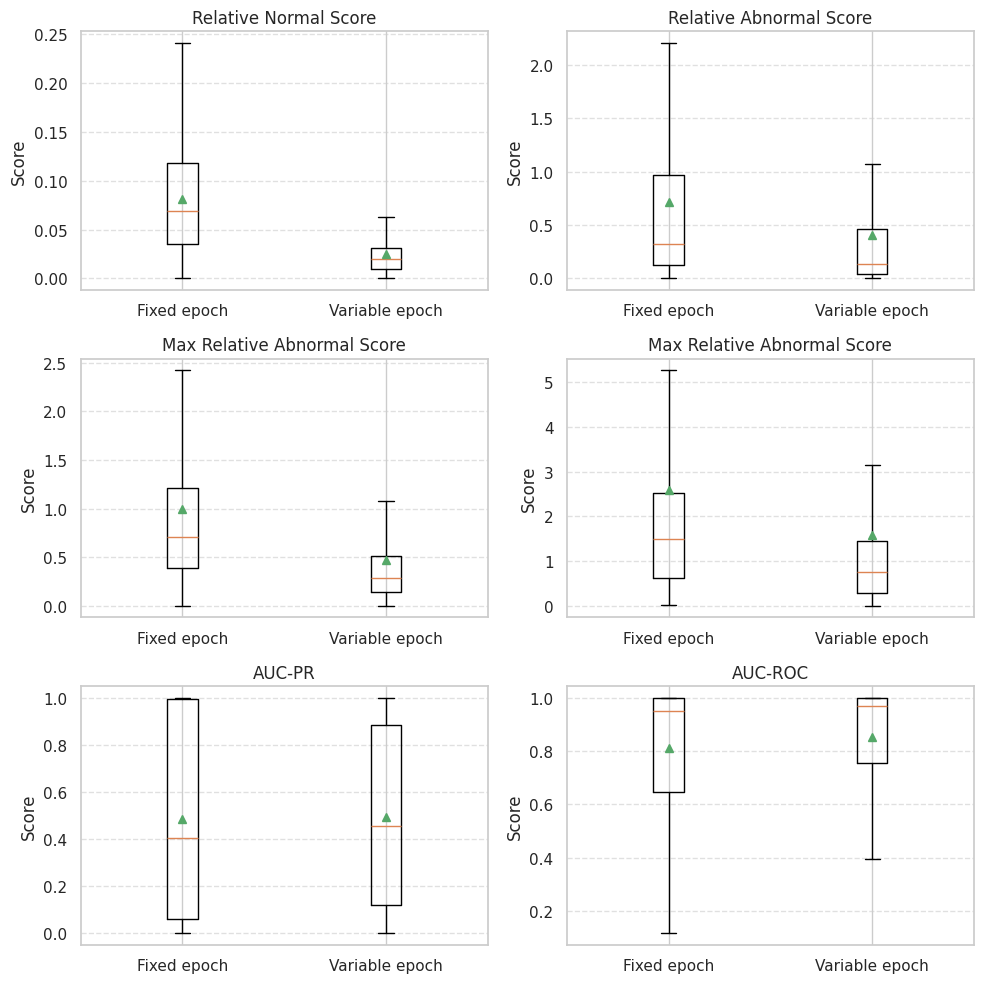

In [25]:
metrics = [
    ("rel_normal", "Relative Normal Score"),
    ("rel_abnormal", "Relative Abnormal Score"),
    ("top1_normal", "Max Relative Abnormal Score"),
    ("top1_abnormal", "Max Relative Abnormal Score"),
    ("AUC-PR", "AUC-PR"),
    ("AUC-ROC", "AUC-ROC"),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    data = [
        timesnet[col],
        timesnet_long[col],
    ]
    
    ax.boxplot(
        data,
        tick_labels=["Fixed epoch", "Variable epoch"],
        showmeans=True,
        showfliers=False
    )
    
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


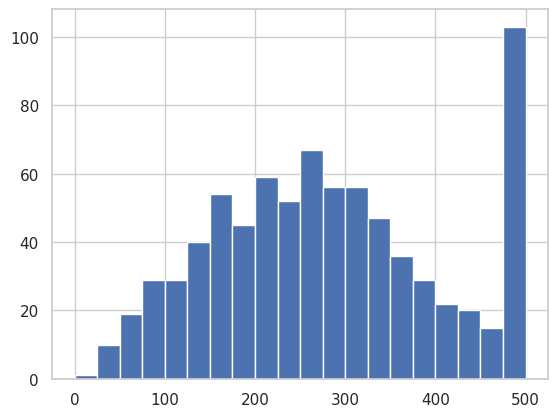

In [28]:
plt.figure()
plt.hist(timesnet_long["stop_epoch"], bins=range(0,501,25))
plt.show()

In [30]:
pd.read_csv("results/Nonstationary_Transformer/32_e2.csv").mean(numeric_only=True)

rel_normal       0.078533
rel_abnormal     0.653762
top1_normal      0.907808
top1_abnormal    2.402497
AUC-PR           0.460978
AUC-ROC          0.801222
Standard-F1      0.488295
dtype: float64